In [1]:
import pandas as pd
import geopandas as geopd

import numpy as np
import os

import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"]  = 400
plt.style.use('dark_background')

# This script modifies flow data for catchments by combining and adjusting flow values.
# It reads flow data from a Parquet file, applies modifications based on predefined combinations,
# calculates specific discharge, and saves the modified flow data and specific discharge as CSV files.

In [2]:
# Read the original flow data
orig_flows = pd.read_parquet("flow/all_flows.parquet")

In [3]:
# Define combinations for temporal sums and stream sums
temporal_sums = ['1181_3743', '1190_1191']
stream_sums = ['1210_2685_2687', '1247_3239', '2687_3160',
               '3086_3216']

# Copy the original flow data to create modified flow data
modified_flows = orig_flows.copy()


# Apply temporal sums
for virtual_gauge in temporal_sums:
    gauges = virtual_gauge.split('_')
    modified_flows[virtual_gauge] = orig_flows[gauges[0]].fillna(orig_flows[gauges[1]])
    modified_flows = modified_flows.drop(gauges, axis=1)

# Apply stream sums
for virtual_gauge in stream_sums:
    gauges = virtual_gauge.split('_')
    modified_flows[virtual_gauge] = orig_flows[gauges].sum(axis=1, skipna=False)
    for gauge in gauges:
        if gauge in modified_flows:
            modified_flows = modified_flows.drop(gauge, axis=1)

# Special case for '1352_1358'
virtual_gauge = '1352_1358'
gauges = virtual_gauge.split('_')
flow = orig_flows[[gauges[1]]]
dam = orig_flows[[gauges[0]]]
dam.index = dam.index + pd.DateOffset(1) 
modified_flows[virtual_gauge] = flow.iloc[:,0] - dam.iloc[:,0]
modified_flows = modified_flows.drop(gauges, axis=1)
modified_flows.loc[modified_flows['1352_1358'] < 0, '1352_1358'] = np.nan

In [22]:
# Read catchment data
catchments_path = "/path/to/CAMELS-FI_catchments.gpkg"
catchments = gpd.read_file(catchments_path, layer='v1')

catchments

,Paikka_Id,area,geometry
0,3544,5.334103e+08,"POLYGON ((469690 7324250, 469690 7324240, 4696..."
1,1315,1.856342e+09,"POLYGON ((525040 7226050, 525040 7226040, 5249..."
2,1316,3.754210e+08,"POLYGON ((539430 7201250, 539430 7201240, 5394..."
3,1317,1.081303e+09,"POLYGON ((485010 7241720, 485010 7241700, 4850..."
4,1318,3.778490e+09,"POLYGON ((485010 7241720, 485010 7241700, 4850..."
5,1346,1.279548e+09,"POLYGON ((469690 7324250, 469690 7324240, 4696..."
6,1347,1.979296e+09,"POLYGON ((467160 7349220, 467160 7349200, 4671..."
7,1349,3.084418e+09,"POLYGON ((467160 7349220, 467160 7349200, 4671..."


<Axes: >

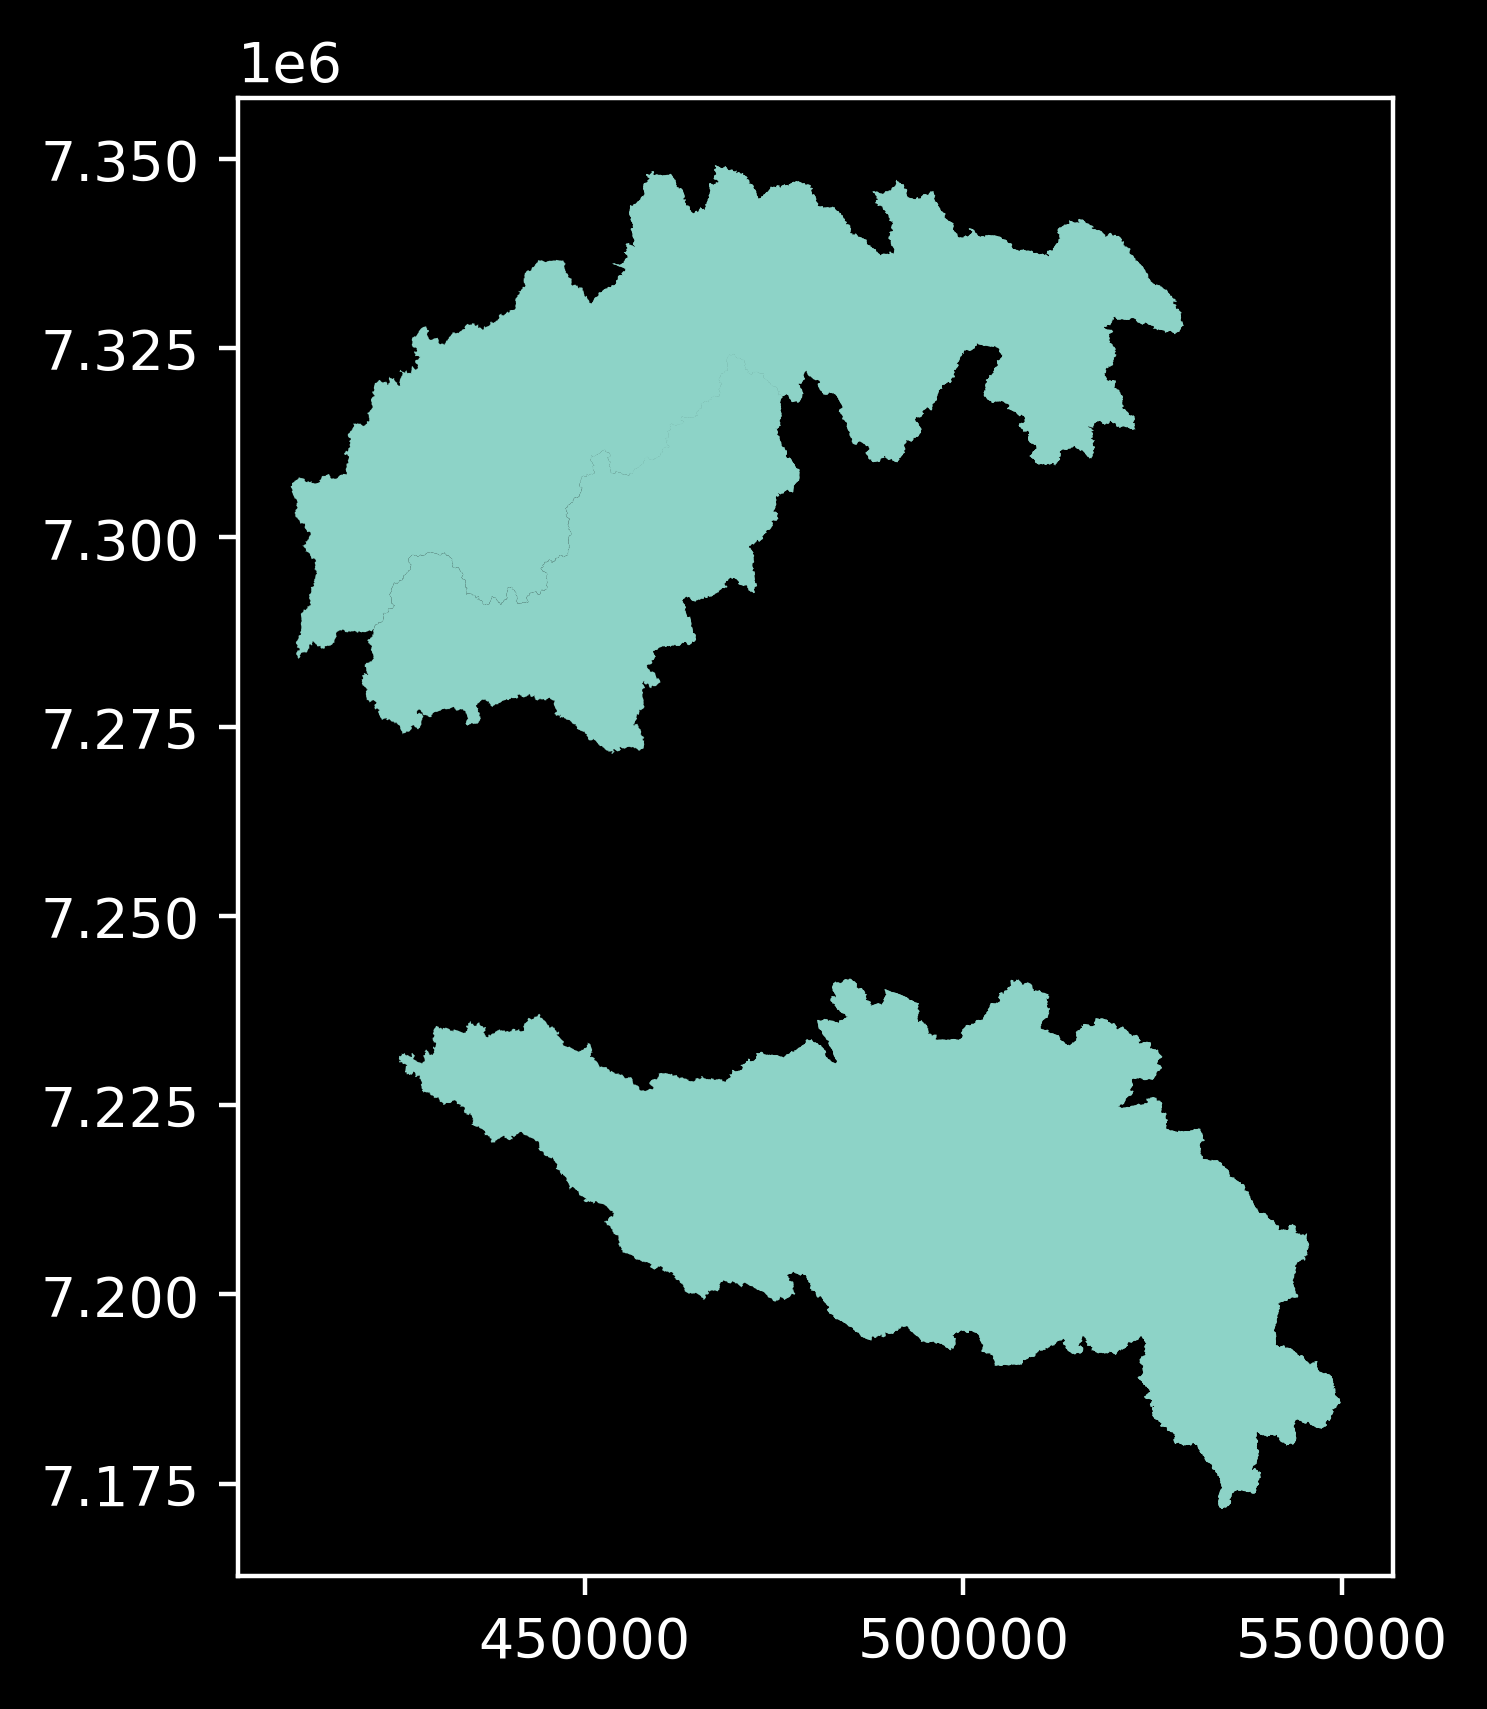

In [10]:
catchments.plot()

<Axes: >

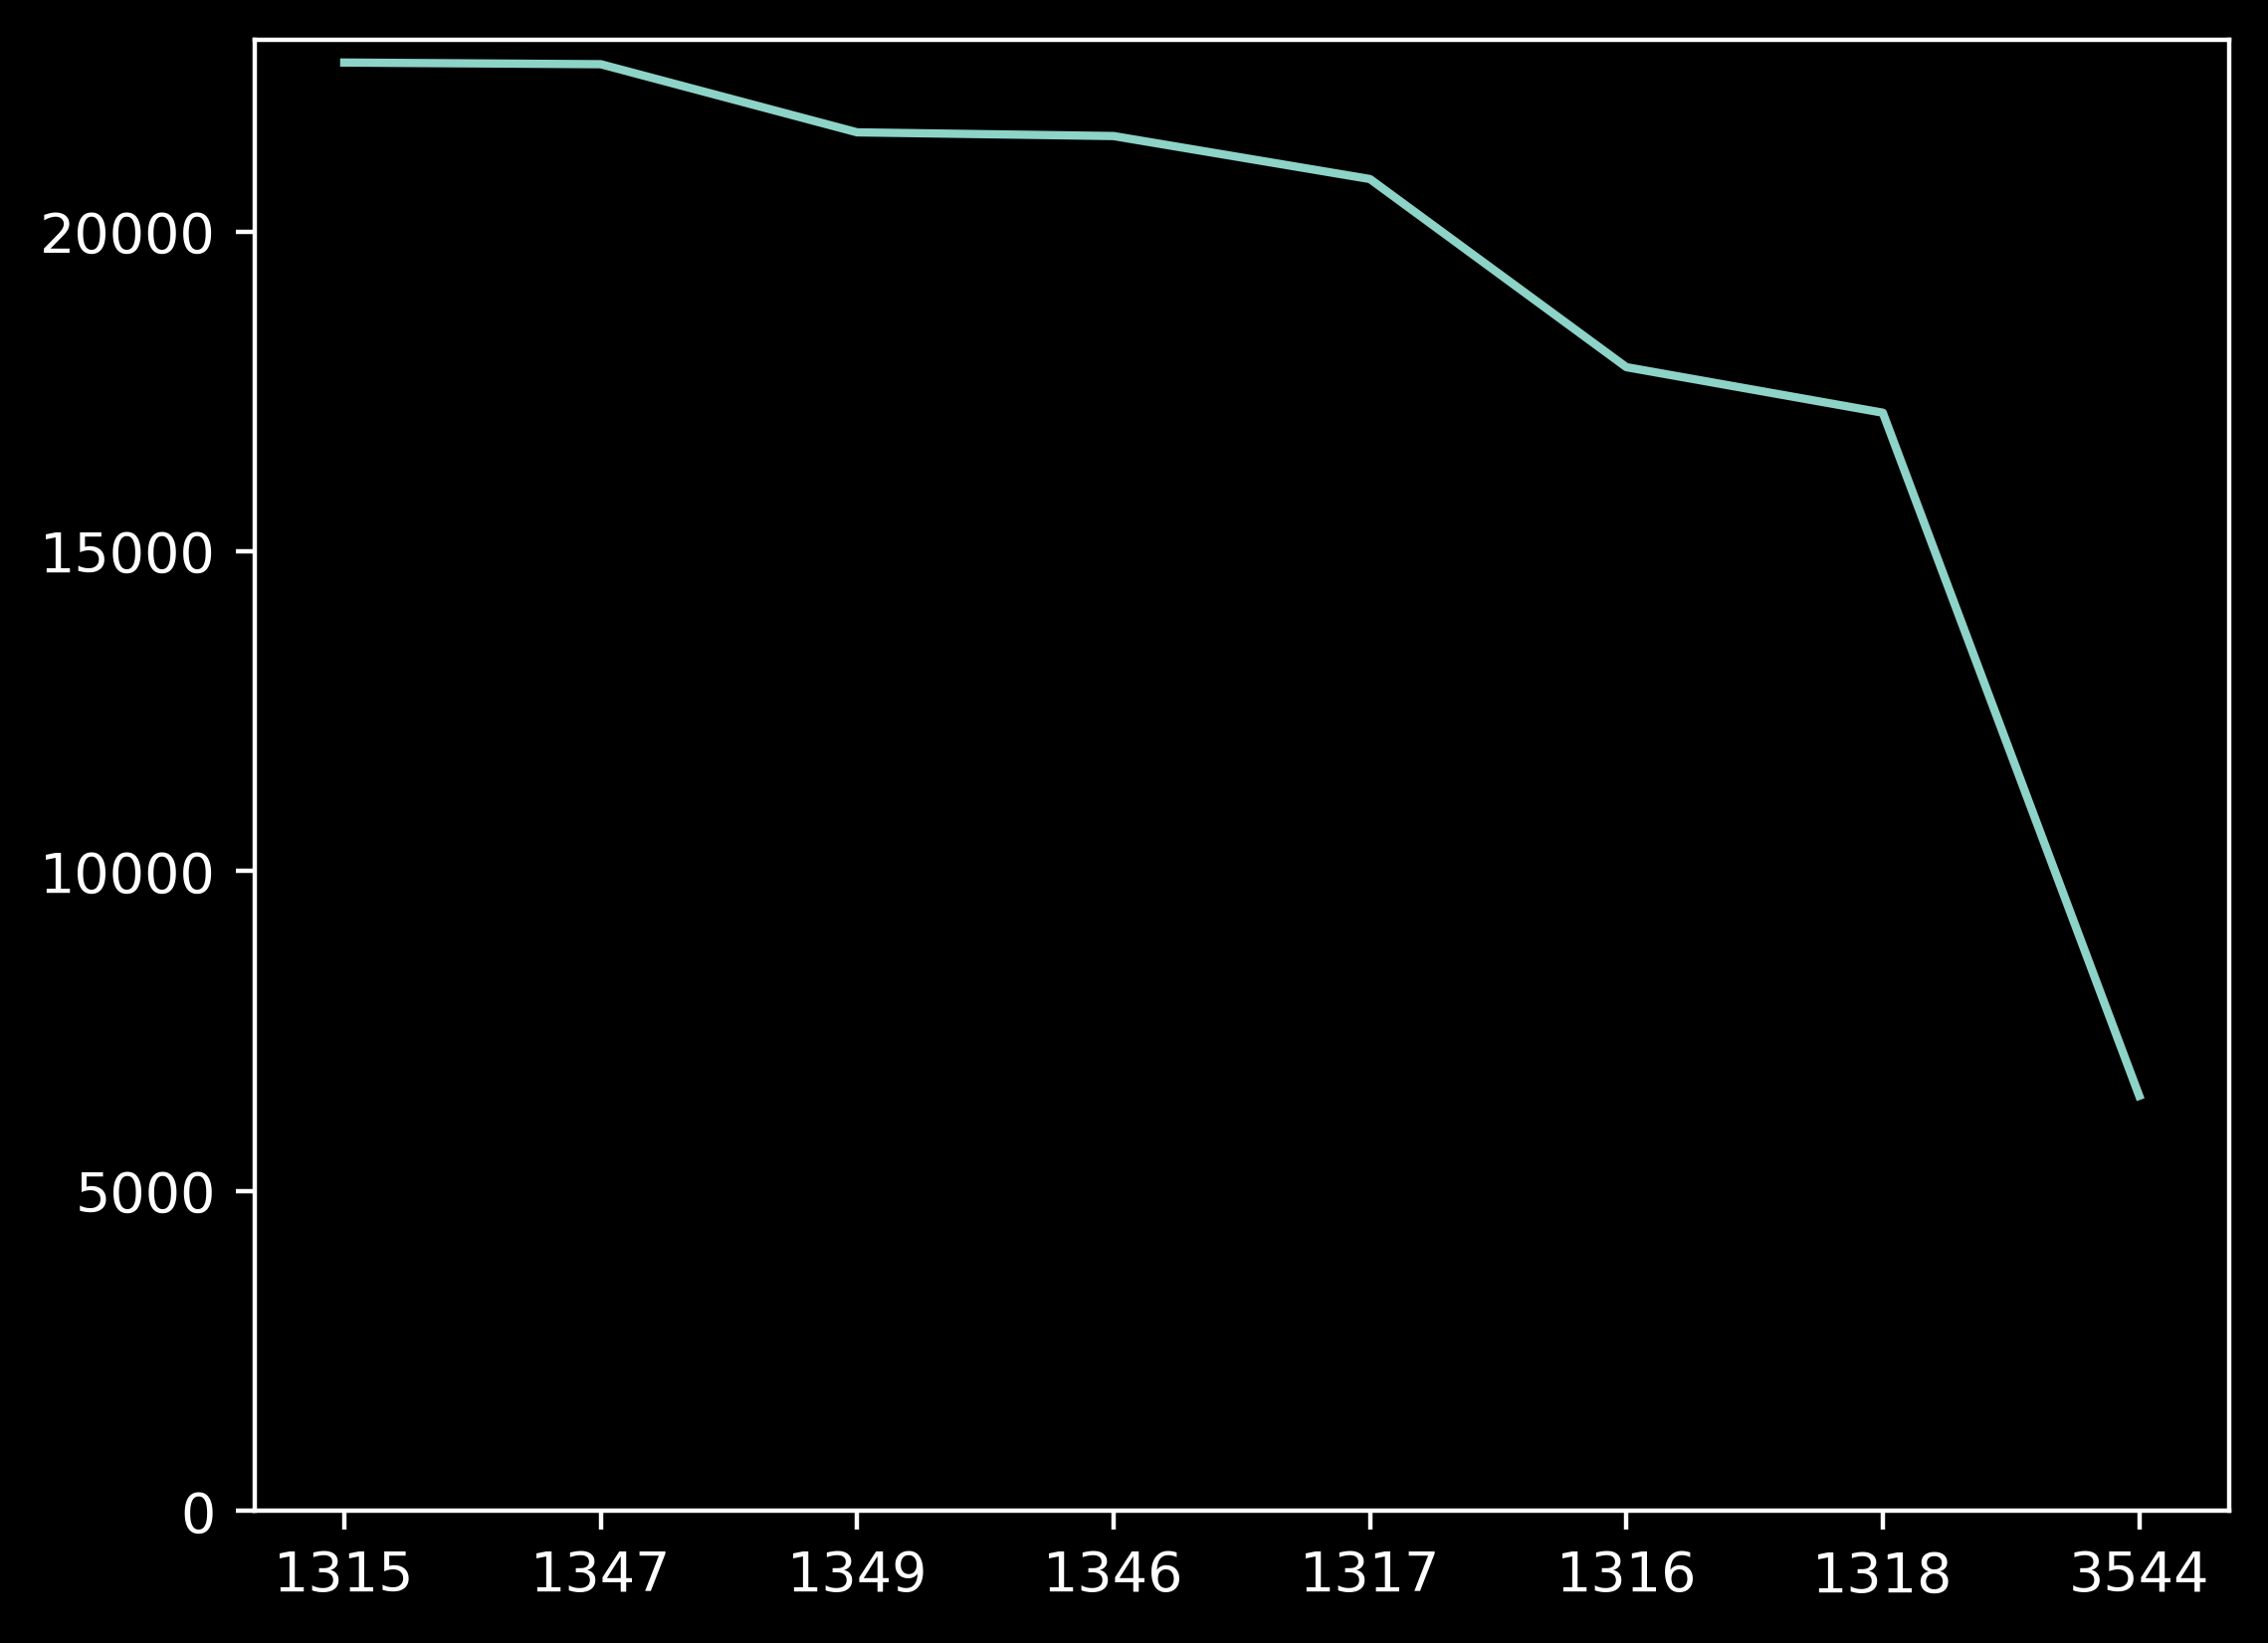

In [18]:
# Filter modified flow data to include only the catchments
modified_flows = modified_flows.loc["1961":"2023", catchments.Paikka_Id]

# Plot the number of non-NA values for each gauge
modified_flows.notna().sum().sort_values(ascending=False).plot(ylim=(0, 23000))

In [ ]:
# Check for at least five years of observations
summation = modified_flows.notna().sum()
print(summation.loc[summation < 1826])

# Check for locations with no observations after 1995
after_1995 = modified_flows["1995":"2023"].notna().sum()
print(after_1995.loc[after_1995 < 1])

In [20]:
# Calculate specific discharge
spec_discharge_list = []
for gauge in modified_flows:
    specific = pd.DataFrame(index=modified_flows.index)
    area = catchments.loc[catchments.Paikka_Id == gauge, 'area'].max()
    # 86_400 is the amount of seconds in day
    specific[gauge] = modified_flows[gauge] * 86_400 / area * 1000 
    spec_discharge_list.append(specific)
    
discharge_spec = pd.concat(spec_discharge_list, axis=1)
discharge_spec = discharge_spec.round(decimals=2)

In [21]:
# Save the specific discharge and modified flow data to CSV files
spec_dst_path = "/path/to/discharge_spec.csv"
flow_dst_path = "/path/to/discharge_vol.csv"

discharge_spec.to_csv(spec_dst_path)
modified_flows.to_csv(flow_dst_path)

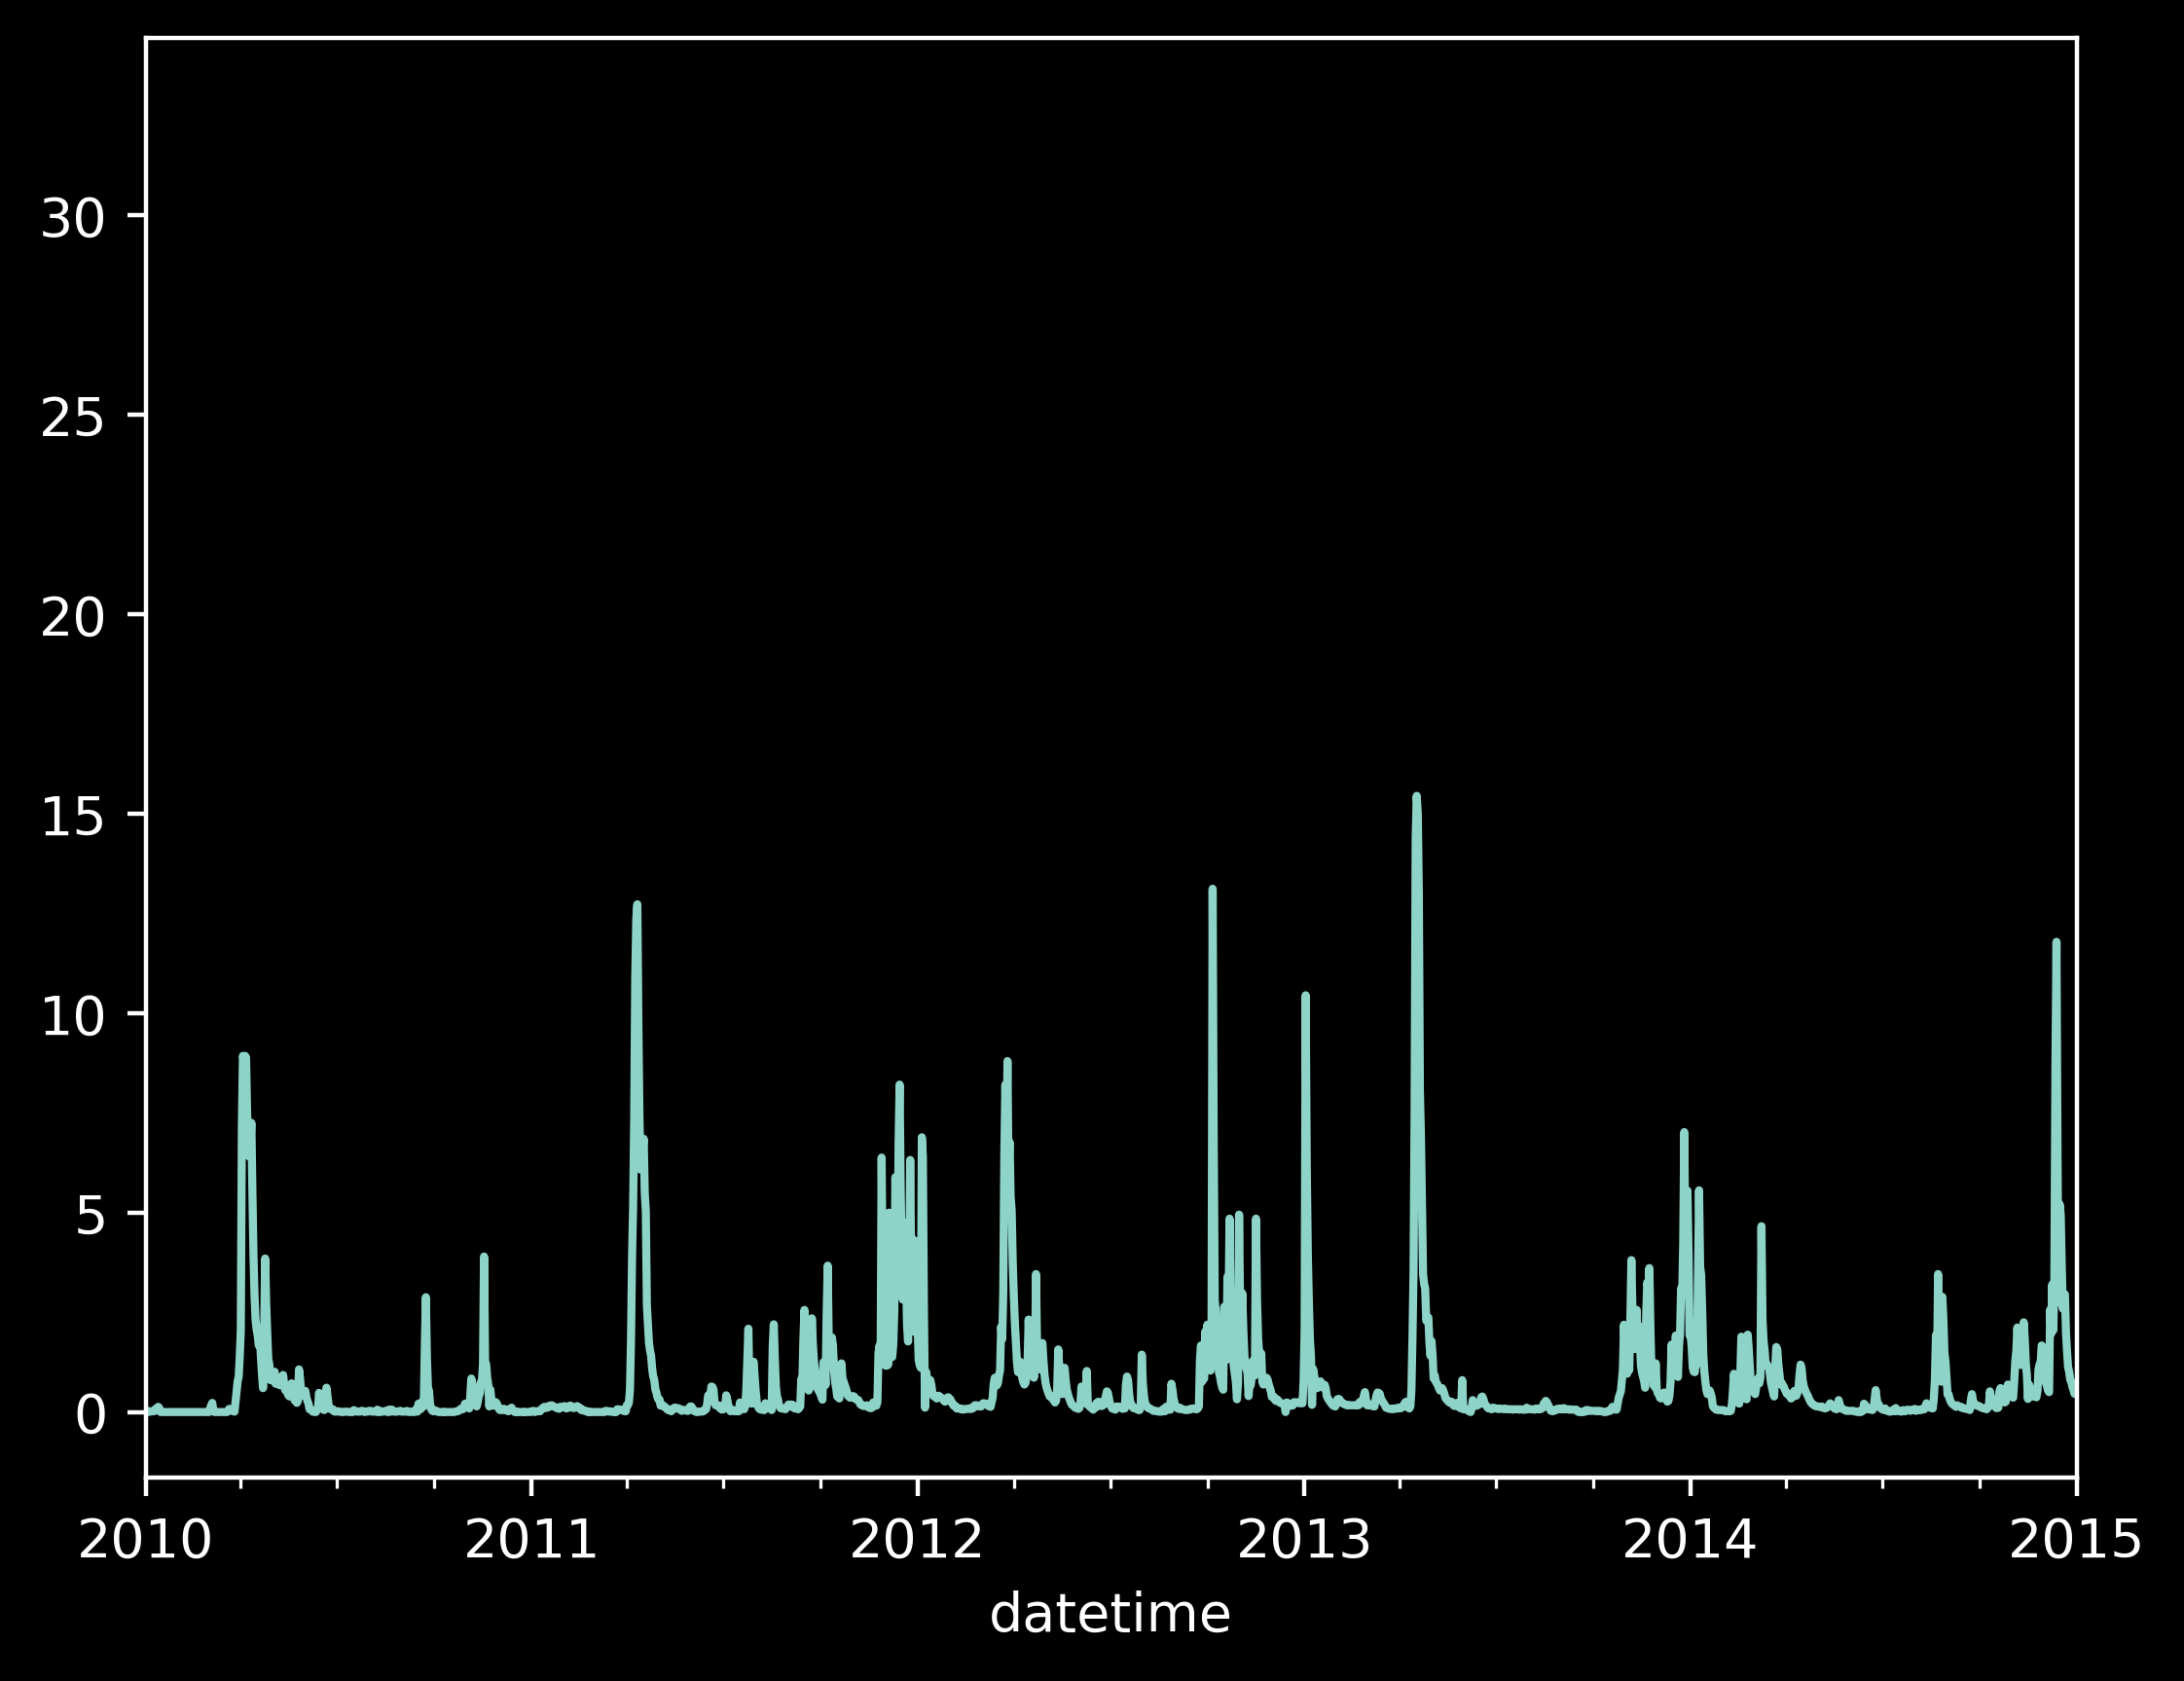

In [22]:
# Plot specific discharge for a specific gauge
ax = discharge_spec['1117'].plot(xlim=("2010", "2015"))

<Axes: >

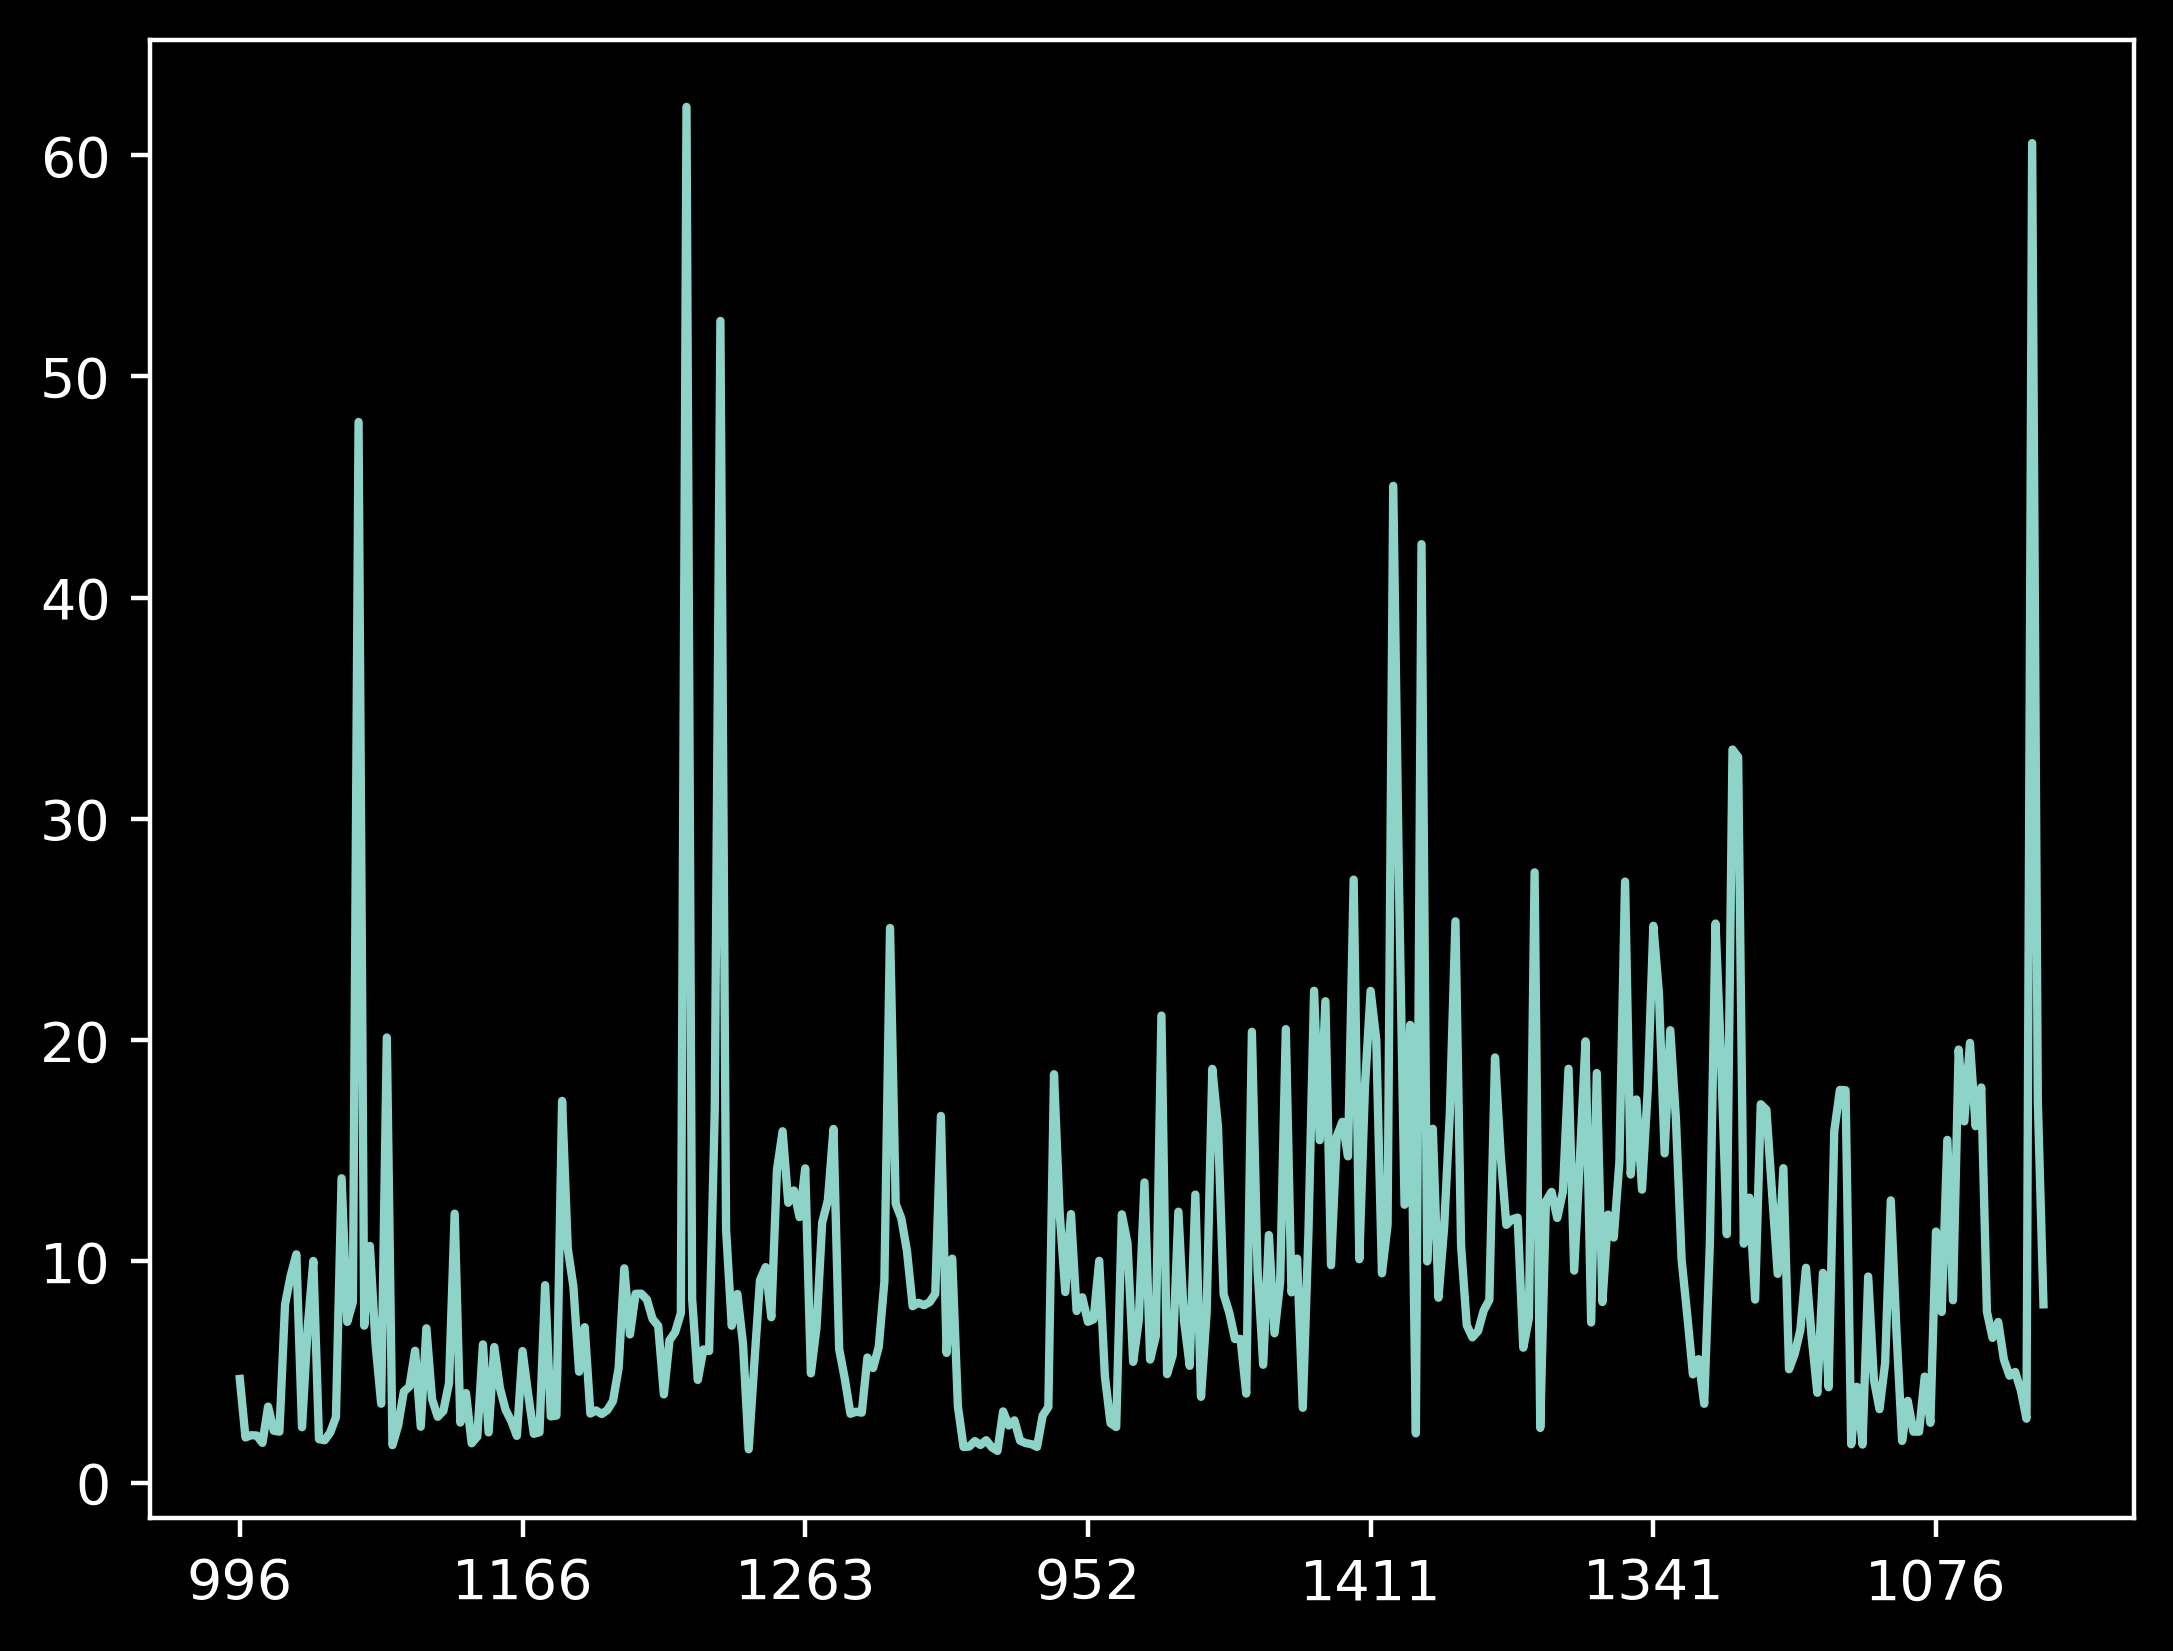

In [13]:
discharge_spec.max().plot()